# SLAP2 Signal Quality Control

This notebook loads SLAP2 glutamate imaging data from the DANDI archive (mirroring `pilot_analysis_rfs.ipynb`) and computes signal-quality metrics per ROI/synapse, primarily SNR. The metrics are designed to flag synapses whose traces are too noisy to be useful for downstream analyses such as receptive field mapping or oddball-response decoding.

Metrics computed per ROI:
- **Baseline noise** — robust std of pre-stimulus baseline windows (MAD-based, immune to spikes).
- **Evoked SNR** — peak of trial-averaged response divided by baseline noise.
- **Mean response z-score** — mean response over the stimulus window in baseline-noise units.
- **Trial reliability** — correlation between mean traces of two random trial halves (split-half).
- **Trace skewness** — highly skewed traces tend to indicate real transients rather than Gaussian noise.

### Import Dependencies

In [83]:
from pathlib import Path
from pynwb import NWBHDF5IO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from dandi import dandiapi, download
import os

In [84]:
output_dir = "./plots_signal_qc"
output_dir = Path(output_dir)
output_dir.mkdir(exist_ok=True)

### Download and Open NWB file
Same DANDI session used in `pilot_analysis_rfs.ipynb` so results are directly comparable to the RF analysis.

In [85]:
dandiset_id = "001424"
dandi_filepath = "sub-794237/sub-794237_ses-20250508T145040_image+ophys.nwb"
download_loc = "."

In [86]:
client = dandiapi.DandiAPIClient()
dandiset = client.get_dandiset(dandiset_id)
file = dandiset.get_asset_by_path(dandi_filepath)
file_url = file.download_url
filename = dandi_filepath.split("/")[-1]
filepath = f"{download_loc}/{filename}"
if os.path.exists(filepath):
    print("File already exists")
else:
    download.download(file_url, output_dir=download_loc)
    print(f"Downloaded file to {filepath}")

File already exists


In [87]:
io = NWBHDF5IO(filepath, mode="r", load_namespaces=True)
nwb = io.read()
nwb

/ems/elsc-labs/segev-i/ido.aizenbud/Installations/miniconda3/lib/python3.11/site-packages/pynwb/file.py:154: UserWarning: Date is missing timezone information. Updating to local timezone.
  args_to_set['date_of_birth'] = _add_missing_timezone(date_of_birth)


Data type,float64
Shape,"(1, 323, 832)"
Array size,2.05 MiB
Chunk shape,None
Compression,None
Compression opts,None
Uncompressed size (bytes),2149888
Compressed size (bytes),2149888
Compression ratio,1.0
Data type,float64
Shape,"(1,)"


### Stimulus Table
Used to define per-trial response and baseline windows for the evoked-SNR metrics.

In [88]:
stim_table = nwb.intervals["stimulus_presentations"].to_dataframe()
print(f"# stimulus presentations: {len(stim_table)}")
stim_table.head()

# stimulus presentations: 5315


,start_time,stop_time,orientation,trial,delay,diameter,x_position,y_position,contrast,spatial_frequency,temporal_frequency
id,,,,,,,,,,,
0,5.150016,5.493016,1.178097,1.0,0.343,360.0,0.0,0.0,1.0,0.04,2.0
1,5.849984,6.192984,0.392699,1.0,0.343,360.0,0.0,0.0,1.0,0.04,2.0
2,6.549984,6.892984,1.963495,1.0,0.343,360.0,0.0,0.0,1.0,0.04,2.0
3,7.249984,7.592984,3.926991,1.0,0.343,360.0,0.0,0.0,1.0,0.04,2.0
4,7.949984,8.292984,2.356194,1.0,0.343,360.0,0.0,0.0,1.0,0.04,2.0


### Inspect ophys structure
Different sessions store traces under different containers (`DfOverF` vs `Fluorescence`) and naming conventions (e.g. `DMD1_DfOverF`, `DMD1_dFF`, `Trial0_DMD1`, …). Print what's actually here so the loader below can be adapted if needed.

In [89]:
ophys = nwb.processing["ophys"]
print("data_interfaces:", list(ophys.data_interfaces.keys()))
for name, iface in ophys.data_interfaces.items():
    rrs = getattr(iface, "roi_response_series", None)
    if rrs is not None:
        names = list(rrs.keys())
        preview = names[:6]
        suffix = "…" if len(names) > 6 else ""
        print(f"  {name} ({type(iface).__name__}) — {len(names)} series: {preview}{suffix}")

data_interfaces: ['DMD1_f0', 'DMD2_f0', 'ImageSegmentation', 'df', 'dff']
  df (Fluorescence) — 2 series: ['DMD1_df', 'DMD2_df']
  dff (DfOverF) — 2 series: ['DMD1_dff', 'DMD2_dff']


### Load dF/F traces
The loader below searches `processing['ophys']` for any RoiResponseSeries that look like dF/F (or falls back to raw fluorescence) and groups them by DMD. Some sessions split traces into per-trial series (`Trial0_DMD1`, `Trial1_DMD1`, …); these are concatenated in time order before computing QC metrics.

In [90]:
import re
from pynwb.ophys import DfOverF, Fluorescence


def _looks_like_dff(name):
    n = name.lower()
    return ("dff" in n) or ("dfoverf" in n) or ("df_over_f" in n) or ("d_f" in n)


def _series_dmd(name):
    m = re.search(r"DMD\s*0*([12])", name, flags=re.IGNORECASE)
    return int(m.group(1)) if m else None


def _series_trial(name):
    m = re.search(r"Trial\s*0*([0-9]+)", name, flags=re.IGNORECASE)
    return int(m.group(1)) if m else None


def collect_dff_series(ophys):
    """Return {dmd: [(trial, name, series), ...]} preferring dF/F-flavored series."""
    candidates = []
    for iface_name, iface in ophys.data_interfaces.items():
        rrs = getattr(iface, "roi_response_series", None)
        if rrs is None:
            continue
        is_dff_iface = isinstance(iface, DfOverF) or _looks_like_dff(iface_name)
        is_fluor_iface = isinstance(iface, Fluorescence) or "fluor" in iface_name.lower()
        for series_name, series in rrs.items():
            dmd = _series_dmd(series_name) or _series_dmd(iface_name)
            if dmd is None:
                continue
            is_dff_series = _looks_like_dff(series_name)
            if is_dff_iface or is_dff_series:
                priority = 0
            elif is_fluor_iface:
                priority = 1
            else:
                priority = 2
            candidates.append((priority, dmd, _series_trial(series_name), series_name, series))

    if not candidates:
        raise RuntimeError("No DMD-tagged RoiResponseSeries found under processing['ophys'].")

    best_priority = min(c[0] for c in candidates)
    by_dmd = {}
    for priority, dmd, trial, name, series in candidates:
        if priority != best_priority:
            continue
        by_dmd.setdefault(dmd, []).append((trial, name, series))
    for dmd in by_dmd:
        by_dmd[dmd].sort(key=lambda x: (x[0] if x[0] is not None else -1, x[1]))
    return by_dmd, best_priority


def load_dff_for_dmd(series_list):
    """Concatenate per-trial series in time order."""
    if len(series_list) == 1:
        s = series_list[0][2]
        return np.asarray(s.data), np.asarray(s.timestamps)
    parts = [(np.asarray(s.timestamps), np.asarray(s.data)) for _, _, s in series_list]
    parts.sort(key=lambda p: p[0][0])
    timestamps = np.concatenate([p[0] for p in parts])
    data = np.concatenate([p[1] for p in parts], axis=0)
    return data, timestamps


by_dmd, priority = collect_dff_series(nwb.processing["ophys"])
trace_kind = {0: "dF/F", 1: "raw fluorescence (no dF/F found)", 2: "unknown response series"}[priority]
print(f"Using: {trace_kind}")

dff_by_dmd = {}
total_rois = 0
for dmd, series_list in sorted(by_dmd.items()):
    names = [n for _, n, _ in series_list[:3]]
    suffix = "…" if len(series_list) > 3 else ""
    print(f"DMD{dmd}: {len(series_list)} series — {names}{suffix}")
    data, timestamps = load_dff_for_dmd(series_list)
    dff_by_dmd[dmd] = {"data": data, "timestamps": timestamps}
    n_t, n_rois = data.shape
    total_rois += n_rois
    print(f"         {n_rois} ROIs, {n_t} timepoints, duration {timestamps[-1] - timestamps[0]:.1f}s")

print(f"Total ROIs across DMDs: {total_rois}")

Using: dF/F
DMD1: 1 series — ['DMD1_dff']
         120 ROIs, 599588 timepoints, duration 3088.4s
DMD2: 1 series — ['DMD2_dff']
         59 ROIs, 599588 timepoints, duration 3088.4s
Total ROIs across DMDs: 179


### Per-ROI quality metrics

For each stimulus presentation we extract a baseline window before stimulus onset and a response window after onset. Per-ROI metrics are aggregated across trials.

- **Robust baseline noise**: 1.4826 · MAD of concatenated baseline samples per ROI. Robust to occasional spontaneous transients in the baseline window.
- **Evoked SNR**: max of trial-averaged response trace / baseline noise.
- **Mean response z**: mean of trial-averaged response / baseline noise.
- **Split-half reliability**: Pearson r between mean response of two random halves of trials, per ROI.

In [91]:
def robust_std(x, axis=0):
    """MAD-based estimate of std, robust to outliers."""
    med = np.nanmedian(x, axis=axis, keepdims=True)
    mad = np.nanmedian(np.abs(x - med), axis=axis)
    return 1.4826 * mad


def extract_trial_segments(dff, timestamps, stim_table,
                           baseline_window=(-0.3, 0.0),
                           response_window=(0.0, 0.35)):
    """Extract per-trial baseline and response segments.

    Default windows are sized for the SLAP2 stim design (~0.343s stim, ~0.36s ITI)
    so baseline does not bleed into the previous trial's response.
    """
    base_segs, resp_segs = [], []
    for _, row in stim_table.iterrows():
        t0 = row["start_time"]
        b0, b1 = np.searchsorted(timestamps, (t0 + baseline_window[0], t0 + baseline_window[1]))
        r0, r1 = np.searchsorted(timestamps, (t0 + response_window[0], t0 + response_window[1]))
        if b1 > b0 and r1 > r0:
            base_segs.append(dff[b0:b1])
            resp_segs.append(dff[r0:r1])
    return base_segs, resp_segs


def compute_qc_metrics(dff, timestamps, stim_table, rng_seed=0,
                       baseline_window=(-0.3, 0.0),
                       response_window=(0.0, 0.35)):
    n_rois = dff.shape[1]
    base_segs, resp_segs = extract_trial_segments(
        dff, timestamps, stim_table,
        baseline_window=baseline_window, response_window=response_window,
    )
    if len(resp_segs) == 0:
        raise RuntimeError("No usable trials — check window sizes vs timestamps.")

    # Pick a target response length from the median trial, then drop trials shorter
    # than that and trim longer ones. Using min() would let a single short trial
    # collapse the time axis to 1 sample and break reliability (zero denominator).
    resp_lens = np.array([seg.shape[0] for seg in resp_segs])
    target_len = int(np.median(resp_lens))
    if target_len < 2:
        dt = float(np.median(np.diff(timestamps)))
        expected = (response_window[1] - response_window[0]) / dt
        raise RuntimeError(
            f"Response segments are too short ({target_len} samples at median; "
            f"~{expected:.1f} expected from window/dt). Reliability needs ≥2 samples — "
            "widen response_window or check timestamp units."
        )
    keep = resp_lens >= target_len
    resp_segs = [s[:target_len] for s, k in zip(resp_segs, keep) if k]
    base_segs = [s for s, k in zip(base_segs, keep) if k]
    n_trials = len(resp_segs)
    n_dropped = int((~keep).sum())

    # Baseline noise: concatenate all kept baseline samples per ROI.
    base_concat = np.concatenate(base_segs, axis=0)
    base_noise = robust_std(base_concat, axis=0)
    base_noise_safe = np.where(base_noise > 0, base_noise, np.nan)

    resp_stack = np.stack(resp_segs, axis=0)  # (trials, time, rois)
    base_means = np.stack([np.nanmean(seg, axis=0) for seg in base_segs], axis=0)
    resp_centered = resp_stack - base_means[:, None, :]

    mean_response_trace = np.nanmean(resp_centered, axis=0)

    # Per-trial peak |response| then mean across trials — robust to heterogeneous
    # stim conditions that would otherwise cancel under simple grand-averaging.
    peak_per_trial = np.nanmax(np.abs(resp_centered), axis=1)
    mean_peak_per_trial = np.nanmean(peak_per_trial, axis=0)
    snr_per_trial = mean_peak_per_trial / base_noise_safe

    peak_response = np.nanmax(np.abs(mean_response_trace), axis=0)
    evoked_snr = peak_response / base_noise_safe

    mean_response = np.nanmean(mean_response_trace, axis=0)
    mean_response_z = mean_response / base_noise_safe

    # Split-half reliability via Pearson r on mean response across the response window.
    rng = np.random.default_rng(rng_seed)
    perm = rng.permutation(n_trials)
    half = n_trials // 2
    a_mean = np.nanmean(resp_centered[perm[:half]], axis=0)
    b_mean = np.nanmean(resp_centered[perm[half:2 * half]], axis=0)
    a_demean = a_mean - np.nanmean(a_mean, axis=0)
    b_demean = b_mean - np.nanmean(b_mean, axis=0)
    num = np.nansum(a_demean * b_demean, axis=0)
    denom = np.sqrt(np.nansum(a_demean ** 2, axis=0) * np.nansum(b_demean ** 2, axis=0))
    reliability = np.where(denom > 0, num / np.where(denom > 0, denom, 1), np.nan)

    skewness = stats.skew(dff, axis=0, nan_policy="omit")

    print(
        f"  using {n_trials} trials at {target_len} response samples each "
        f"({n_dropped} short trials dropped)"
    )

    return pd.DataFrame({
        "roi": np.arange(n_rois),
        "baseline_noise": base_noise,
        "peak_response": peak_response,
        "evoked_snr": evoked_snr,
        "snr_per_trial": snr_per_trial,
        "mean_response_z": mean_response_z,
        "reliability": reliability,
        "skewness": skewness,
    }), mean_response_trace

In [92]:
qc_results = {}
for dmd in sorted(dff_by_dmd):
    metrics_df, mean_resp = compute_qc_metrics(
        dff_by_dmd[dmd]["data"],
        dff_by_dmd[dmd]["timestamps"],
        stim_table,
    )
    qc_results[dmd] = {"metrics": metrics_df, "mean_response_trace": mean_resp}
    print(f"DMD{dmd}: {len(metrics_df)} ROIs")
    print(metrics_df.describe().round(3))

/tmp/ipykernel_3008140/1208641883.py:63: RuntimeWarning: Mean of empty slice
  base_means = np.stack([np.nanmean(seg, axis=0) for seg in base_segs], axis=0)
/tmp/ipykernel_3008140/1208641883.py:70: RuntimeWarning: All-NaN slice encountered
  peak_per_trial = np.nanmax(np.abs(resp_centered), axis=1)


  using 4987 trials at 70 response samples each (191 short trials dropped)
DMD1: 120 ROIs
           roi  baseline_noise  peak_response  evoked_snr  snr_per_trial  \
count  120.000         120.000        120.000     120.000        120.000   
mean    59.500           0.352          0.081       0.234          3.039   
std     34.785           0.087          0.055       0.154          0.297   
min      0.000           0.212          0.013       0.054          2.631   
25%     29.750           0.301          0.049       0.152          2.849   
50%     59.500           0.333          0.066       0.188          2.988   
75%     89.250           0.391          0.094       0.258          3.181   
max    119.000           0.619          0.407       1.246          4.992   

       mean_response_z  reliability  skewness  
count          120.000      120.000   120.000  
mean             0.023        0.891     1.341  
std              0.095        0.173     0.521  
min             -0.331       -0.0

/tmp/ipykernel_3008140/1208641883.py:63: RuntimeWarning: Mean of empty slice
  base_means = np.stack([np.nanmean(seg, axis=0) for seg in base_segs], axis=0)
/tmp/ipykernel_3008140/1208641883.py:70: RuntimeWarning: All-NaN slice encountered
  peak_per_trial = np.nanmax(np.abs(resp_centered), axis=1)


  using 4987 trials at 70 response samples each (191 short trials dropped)
DMD2: 59 ROIs
          roi  baseline_noise  peak_response  evoked_snr  snr_per_trial  \
count  59.000          59.000         59.000      59.000         59.000   
mean   29.000           0.389          0.085       0.225          2.989   
std    17.176           0.127          0.044       0.111          0.247   
min     0.000           0.147          0.020       0.076          2.515   
25%    14.500           0.306          0.050       0.139          2.829   
50%    29.000           0.360          0.070       0.206          2.947   
75%    43.500           0.480          0.111       0.286          3.129   
max    58.000           0.718          0.196       0.580          3.764   

       mean_response_z  reliability  skewness  
count           59.000       59.000    59.000  
mean             0.013        0.908     1.299  
std              0.091        0.110     0.522  
min             -0.250        0.480     0.5

### Metric distributions
Histograms of each metric per DMD. Long right tails on `evoked_snr` / `reliability` / `skewness` are good — they identify the responsive subset.

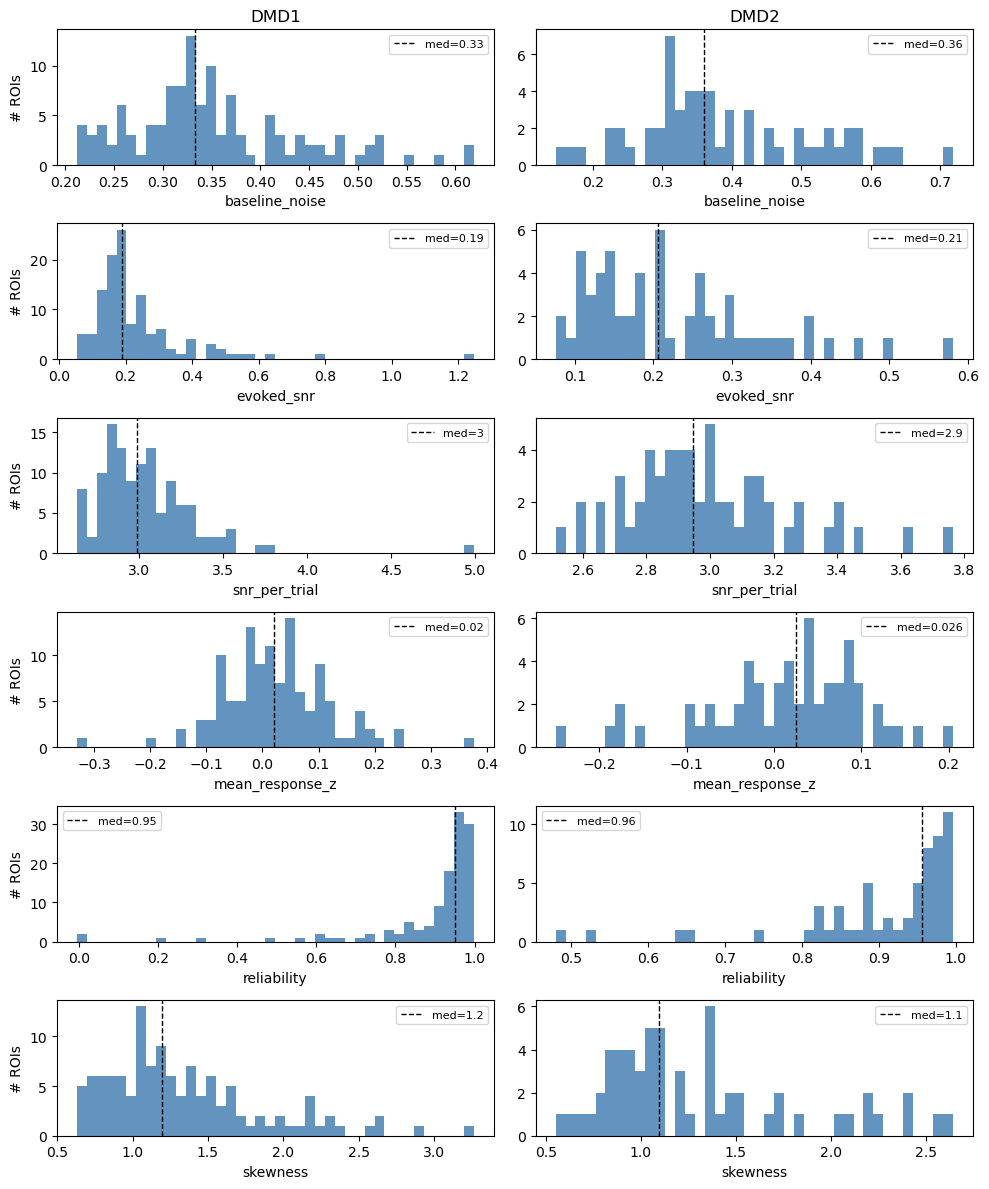

In [93]:
metric_cols = ["baseline_noise", "evoked_snr", "snr_per_trial", "mean_response_z", "reliability", "skewness"]
dmds = sorted(qc_results)
fig, axs = plt.subplots(len(metric_cols), len(dmds), figsize=(5 * len(dmds), 2.0 * len(metric_cols)),
                        sharey=False, squeeze=False)
for col_i, dmd in enumerate(dmds):
    df = qc_results[dmd]["metrics"]
    for row_i, m in enumerate(metric_cols):
        ax = axs[row_i, col_i]
        vals = df[m].dropna().values
        ax.hist(vals, bins=40, color="steelblue", alpha=0.85)
        ax.axvline(np.nanmedian(vals), color="k", linestyle="--", lw=1, label=f"med={np.nanmedian(vals):.2g}")
        ax.set_xlabel(m)
        if col_i == 0:
            ax.set_ylabel("# ROIs")
        if row_i == 0:
            ax.set_title(f"DMD{dmd}")
        ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(output_dir / "metric_distributions.png", dpi=150)
plt.show()

### Metric relationships
Two views that are useful for picking a QC threshold:
1. `evoked_snr` vs `reliability` — a responsive ROI should be high in both.
2. `baseline_noise` vs `peak_response` — the diagonals are iso-SNR contours; ROIs above the diagonal are responsive.

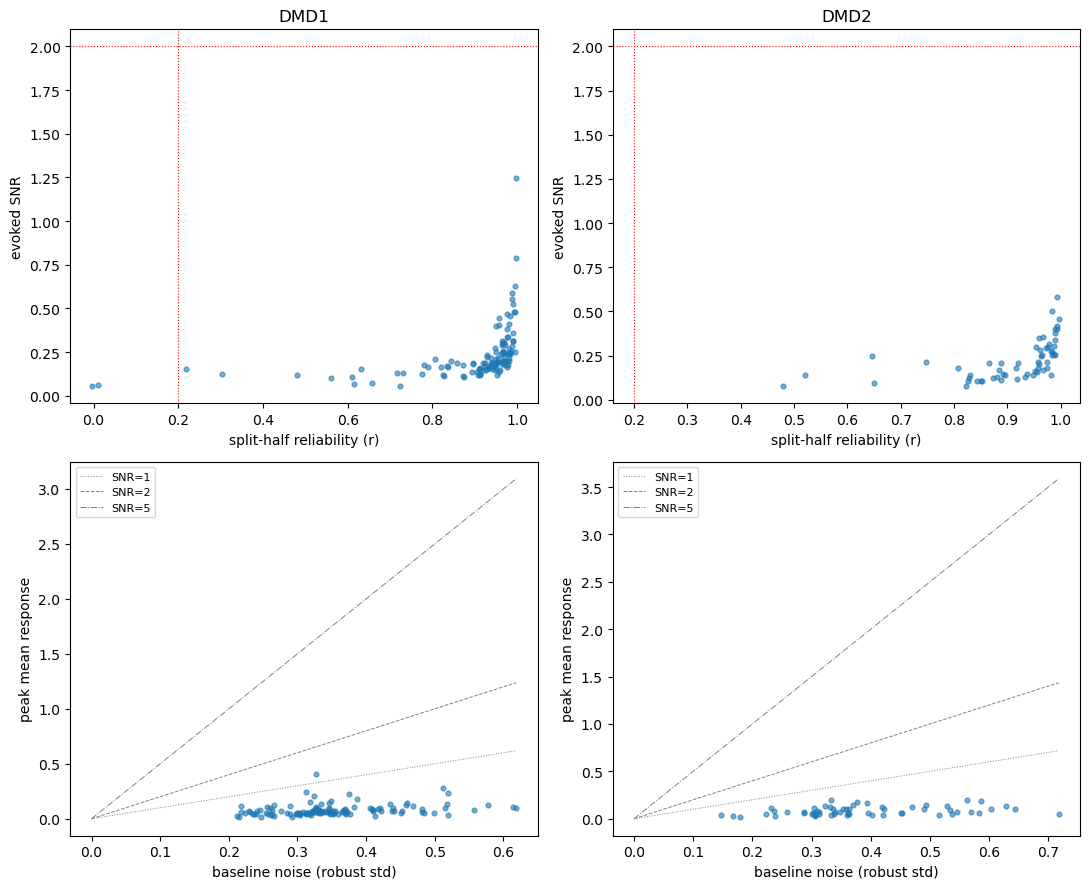

In [94]:
dmds = sorted(qc_results)
fig, axs = plt.subplots(2, len(dmds), figsize=(5.5 * len(dmds), 9), squeeze=False)
for col_i, dmd in enumerate(dmds):
    df = qc_results[dmd]["metrics"]
    ax = axs[0, col_i]
    ax.scatter(df["reliability"], df["evoked_snr"], s=12, alpha=0.6)
    ax.set_xlabel("split-half reliability (r)")
    ax.set_ylabel("evoked SNR")
    ax.set_title(f"DMD{dmd}")
    ax.axhline(2, color="r", lw=0.8, ls=":")
    ax.axvline(0.2, color="r", lw=0.8, ls=":")

    ax = axs[1, col_i]
    ax.scatter(df["baseline_noise"], df["peak_response"], s=12, alpha=0.6)
    lim = max(df["baseline_noise"].max(), df["peak_response"].max())
    xs = np.linspace(0, lim, 100)
    for k, ls in [(1, ":"), (2, "--"), (5, "-.")]:
        ax.plot(xs, k * xs, color="gray", lw=0.7, ls=ls, label=f"SNR={k}")
    ax.set_xlabel("baseline noise (robust std)")
    ax.set_ylabel("peak mean response")
    ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
fig.savefig(output_dir / "metric_relationships.png", dpi=150)
plt.show()

### Example traces: high vs low SNR
Trial-averaged response trace, plus a short snippet of the raw trace, for the top-5 and bottom-5 ROIs by evoked SNR. Sanity check that the metric is picking out responsive vs noise-only synapses.

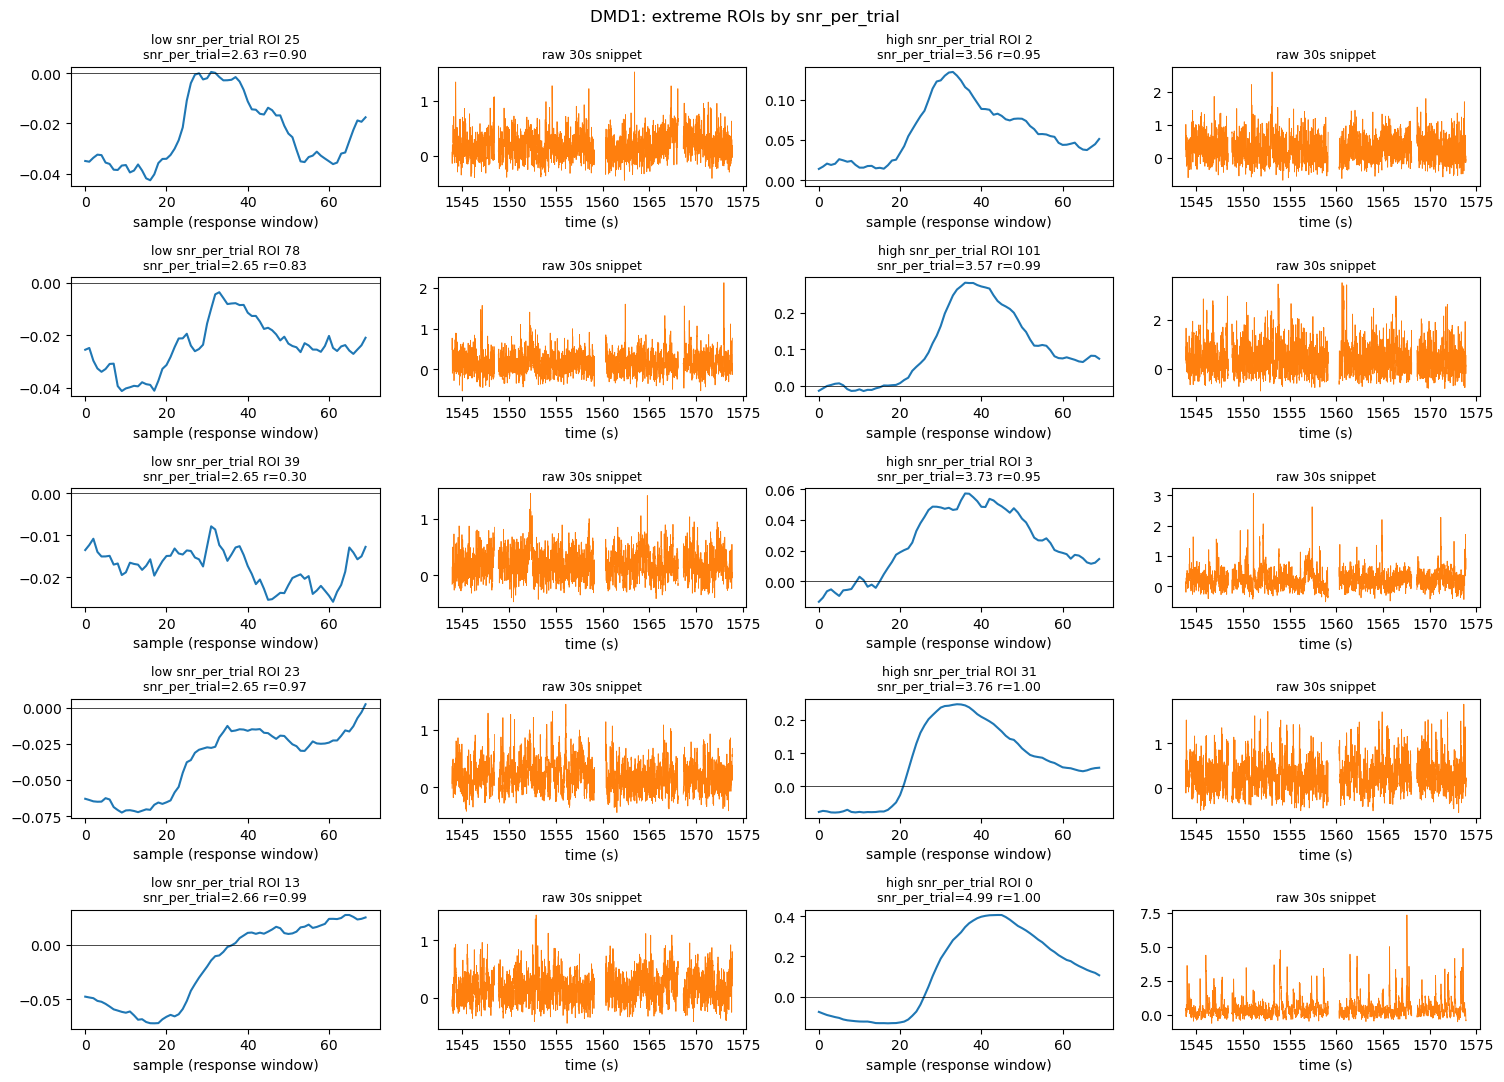

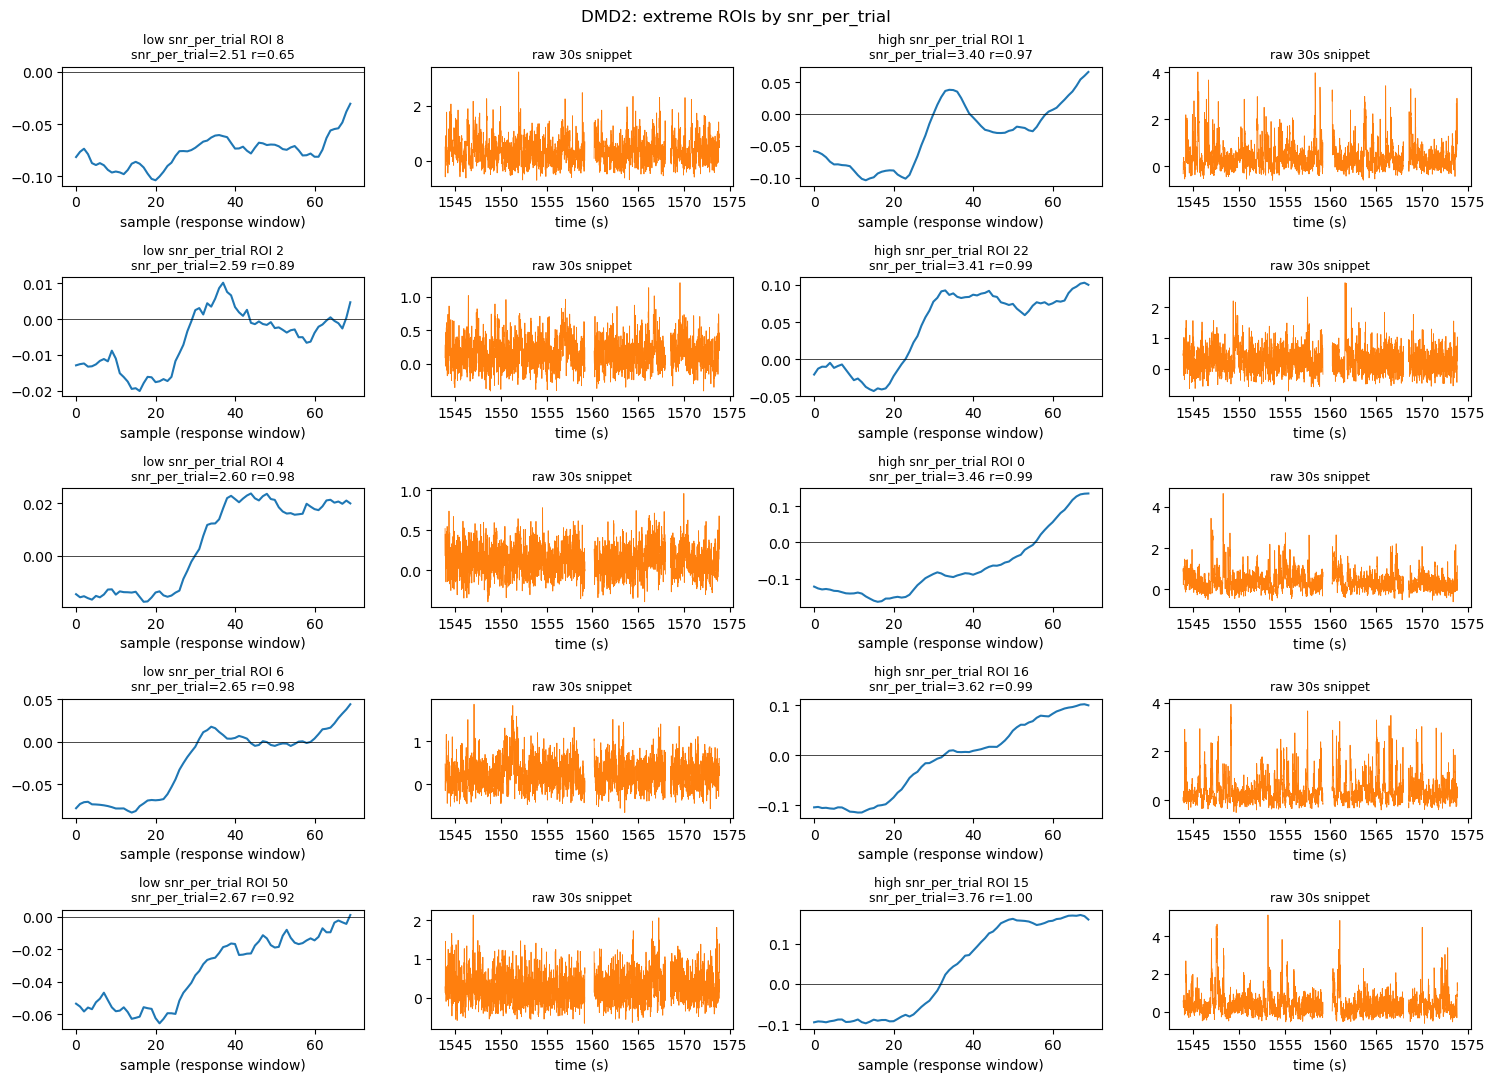

In [95]:
def plot_examples(dmd, n=5, sort_by="snr_per_trial"):
    metrics = qc_results[dmd]["metrics"]
    mean_trace = qc_results[dmd]["mean_response_trace"]
    dff = dff_by_dmd[dmd]["data"]
    timestamps = dff_by_dmd[dmd]["timestamps"]

    sorted_df = metrics.dropna(subset=[sort_by]).sort_values(sort_by)
    n = min(n, len(sorted_df) // 2)
    if n == 0:
        print(f"DMD{dmd}: not enough ROIs with {sort_by} to plot.")
        return
    low_rois = sorted_df.head(n)["roi"].astype(int).tolist()
    high_rois = sorted_df.tail(n)["roi"].astype(int).tolist()

    mid = len(timestamps) // 2
    snippet_t0 = timestamps[mid]
    snippet_idx = (timestamps >= snippet_t0) & (timestamps <= snippet_t0 + 30.0)

    fig, axs = plt.subplots(n, 4, figsize=(15, 2.2 * n), squeeze=False)
    for i in range(n):
        for j, (rois, label) in enumerate([(low_rois, f"low {sort_by}"), (high_rois, f"high {sort_by}")]):
            roi = rois[i]
            metric_val = metrics.loc[roi, sort_by]
            rel = metrics.loc[roi, "reliability"]
            ax = axs[i, 2 * j]
            ax.plot(mean_trace[:, roi], color="C0")
            ax.axhline(0, color="k", lw=0.5)
            ax.set_title(f"{label} ROI {roi}\n{sort_by}={metric_val:.2f} r={rel:.2f}", fontsize=9)
            ax.set_xlabel("sample (response window)")
            ax = axs[i, 2 * j + 1]
            ax.plot(timestamps[snippet_idx], dff[snippet_idx, roi], color="C1", lw=0.6)
            ax.set_xlabel("time (s)")
            ax.set_title("raw 30s snippet", fontsize=9)
    fig.suptitle(f"DMD{dmd}: extreme ROIs by {sort_by}")
    fig.tight_layout()
    fig.savefig(output_dir / f"examples_dmd{dmd}.png", dpi=150)
    plt.show()


for dmd in sorted(qc_results):
    plot_examples(dmd)

### Spatial map of SNR over the segmentation
Overlay per-ROI `snr_per_trial` on the DMD mean image. SLAP2 only images selected pixels in the FOV, so the map is cropped to the bounding box of mask coverage and shown over the mean image (NaN regions are transparent). Useful for spotting whether low-SNR ROIs cluster in particular regions (e.g. out-of-plane, dim, or photobleached areas).

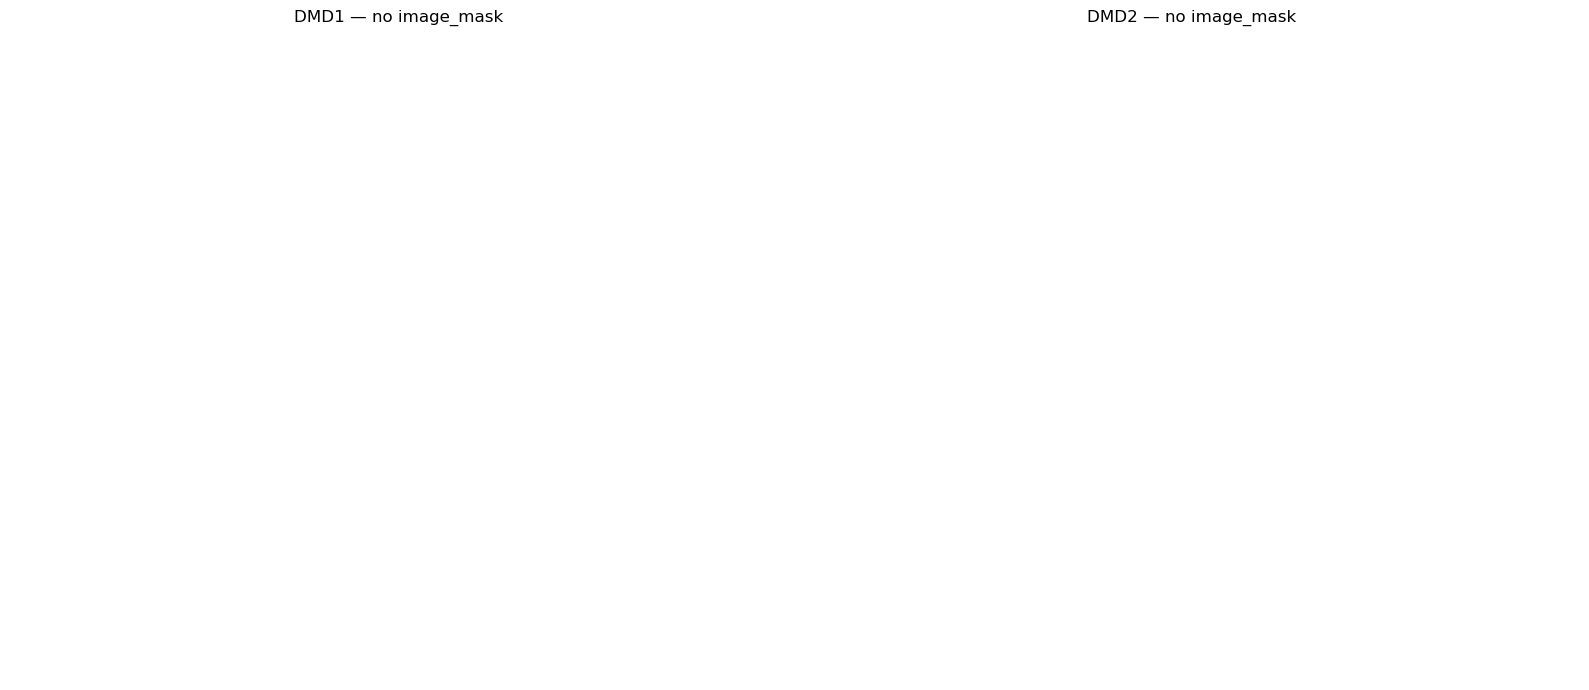

In [96]:
def find_plane_segmentation(nwb, dmd):
    if "ImageSegmentation" not in nwb.processing["ophys"].data_interfaces:
        return None
    img_seg = nwb.processing["ophys"]["ImageSegmentation"]
    for name in img_seg.plane_segmentations:
        if re.search(rf"DMD\s*0*{dmd}\b", name, flags=re.IGNORECASE):
            return img_seg.plane_segmentations[name]
    return None


def find_mean_image(nwb, dmd):
    for name, acq in nwb.acquisition.items():
        if "ImageSeries" in str(type(acq)) and re.search(rf"DMD\s*0*{dmd}\b.*mean", name, flags=re.IGNORECASE):
            data = np.asarray(acq.data)
            return data[0] if data.ndim == 3 else data
    return None


def mask_centroids_and_areas(image_masks):
    """Return (n_rois, 2) array of (y, x) centroids and (n_rois,) areas."""
    n_rois = image_masks.shape[0]
    centroids = np.full((n_rois, 2), np.nan)
    areas = np.zeros(n_rois)
    for i in range(n_rois):
        m = image_masks[i]
        total = m.sum()
        areas[i] = (m > 0).sum()
        if total > 0:
            ys, xs = np.indices(m.shape)
            centroids[i, 0] = (ys * m).sum() / total
            centroids[i, 1] = (xs * m).sum() / total
    return centroids, areas


metric_for_map = "snr_per_trial"

dmds = sorted(qc_results)
fig, axs = plt.subplots(1, len(dmds), figsize=(8 * len(dmds), 7), squeeze=False)
for col_i, dmd in enumerate(dmds):
    ax = axs[0, col_i]
    plane_seg = find_plane_segmentation(nwb, dmd)
    if plane_seg is None or "image_mask" not in plane_seg.colnames:
        ax.set_title(f"DMD{dmd} — no image_mask")
        ax.axis("off")
        continue
    image_masks = np.asarray(plane_seg["image_mask"][:])
    metric_vals = qc_results[dmd]["metrics"][metric_for_map].values
    n_rois = image_masks.shape[0]
    print(
        f"DMD{dmd}: image_masks shape {image_masks.shape}, dtype {image_masks.dtype}, "
        f"value range [{image_masks.min():.3g}, {image_masks.max():.3g}], "
        f"nonzero pixels {int((image_masks > 0).sum())}"
    )
    if n_rois != len(metric_vals):
        ax.set_title(f"DMD{dmd} — ROI count mismatch")
        ax.axis("off")
        continue

    centroids, areas = mask_centroids_and_areas(image_masks)
    valid = np.isfinite(centroids[:, 0]) & np.isfinite(metric_vals)
    if not valid.any():
        ax.set_title(f"DMD{dmd} — no valid centroids")
        ax.axis("off")
        continue

    h, w = image_masks.shape[1:]
    pad = 30
    y_centroids = centroids[valid, 0]
    x_centroids = centroids[valid, 1]
    y0 = max(0, int(y_centroids.min()) - pad)
    y1 = min(h, int(y_centroids.max()) + pad + 1)
    x0 = max(0, int(x_centroids.min()) - pad)
    x1 = min(w, int(x_centroids.max()) + pad + 1)

    mean_img = find_mean_image(nwb, dmd)
    if mean_img is not None and mean_img.shape[:2] == (h, w):
        bg = mean_img[y0:y1, x0:x1]
        ax.imshow(bg, cmap="gray", origin="upper",
                  vmin=np.nanpercentile(bg, 1), vmax=np.nanpercentile(bg, 99),
                  extent=(x0, x1, y1, y0))
    else:
        ax.set_xlim(x0, x1)
        ax.set_ylim(y1, y0)
        ax.set_facecolor("#202020")

    vals = metric_vals[valid]
    vmin, vmax = float(np.nanpercentile(vals, 1)), float(np.nanpercentile(vals, 99))
    if vmax <= vmin:
        vmax = vmin + 1e-6
    sizes = 20 + 0.5 * areas[valid]  # bigger ROIs get bigger dots
    sc = ax.scatter(x_centroids, y_centroids, c=vals, cmap="magma",
                    vmin=vmin, vmax=vmax, s=sizes, edgecolors="white", linewidths=0.4, alpha=0.95)
    ax.set_title(
        f"DMD{dmd} — {metric_for_map} per ROI ({int(valid.sum())} ROIs)\n"
        f"range [{vmin:.3g}, {vmax:.3g}]"
    )
    ax.set_aspect("equal")
    ax.set_xlabel("x (px)")
    ax.set_ylabel("y (px)")
    plt.colorbar(sc, ax=ax, fraction=0.045, label=metric_for_map)

fig.tight_layout()
fig.savefig(output_dir / "snr_spatial.png", dpi=150)
plt.show()

### Summary table & threshold suggestion
Pass criterion below uses `snr_per_trial` (mean of per-trial peak |response|, in baseline-noise units) — more meaningful than `evoked_snr` for this stim design because each ROI typically responds to one orientation × one RF position, so averaging the trace across all 5315 trials would cancel signal. With raw ΔF and a (-0.3s, 0s) baseline that fits inside the ITI, expect modest absolute SNR values; tune the threshold to your downstream analysis.

In [ ]:
# Calibrating thresholds for THIS dataset (see the printed quantiles below):
#  - snr_per_trial median ≈ 2.95–3.0 — that IS the noise floor for ~70-sample trials
#    (E[max |z|] over 70 i.i.d. normals ≈ √(2·ln 70) ≈ 2.9). Set the threshold above
#    p75 (~3.2) to require ROIs that are clearly above the noise expectation.
#  - reliability is ≥0.9 for almost every ROI here (a global onset transient drives
#    a similar mean shape everywhere). It's only useful for catching outliers, so set
#    a permissive threshold (e.g. 0.7) and let snr_per_trial do the real filtering.
snr_per_trial_threshold = 3.3
reliability_threshold = 0.7

# Report distribution quantiles to help calibrate the thresholds.
print("Quantiles per DMD (helps you pick thresholds from the data):")
for dmd in sorted(qc_results):
    df = qc_results[dmd]["metrics"]
    qs = [50, 75, 90, 95, 99]
    snr_q = np.nanpercentile(df["snr_per_trial"], qs)
    rel_q = np.nanpercentile(df["reliability"], qs)
    print(f"  DMD{dmd}  snr_per_trial   p{qs} = {np.round(snr_q, 3).tolist()}")
    print(f"          reliability     p{qs} = {np.round(rel_q, 3).tolist()}")
print(f"\nUsing snr_per_trial >= {snr_per_trial_threshold}, reliability >= {reliability_threshold}")

summary_rows = []
for dmd in sorted(qc_results):
    df = qc_results[dmd]["metrics"].copy()
    df["pass_qc"] = (df["snr_per_trial"] >= snr_per_trial_threshold) & (df["reliability"] >= reliability_threshold)
    qc_results[dmd]["metrics"] = df
    df.to_csv(output_dir / f"qc_metrics_dmd{dmd}.csv", index=False)
    summary_rows.append({
        "dmd": dmd,
        "n_rois": len(df),
        "n_pass": int(df["pass_qc"].sum()),
        "frac_pass": float(df["pass_qc"].mean()),
        "median_snr_per_trial": float(df["snr_per_trial"].median()),
        "median_evoked_snr": float(df["evoked_snr"].median()),
        "median_reliability": float(df["reliability"].median()),
    })
summary_df = pd.DataFrame(summary_rows)
print()
print(summary_df.to_string(index=False))
summary_df.to_csv(output_dir / "qc_summary.csv", index=False)